In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Tải dữ liệu
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# Xem 5 dòng đầu tiên
print("Dữ liệu 5 dòng đầu:")
display(df.head())

# Kiểm tra thông tin tổng quát (missing values, data types)
print("\nThông tin bộ dữ liệu:")
df.info()

Dữ liệu 5 dòng đầu:


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



Thông tin bộ dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


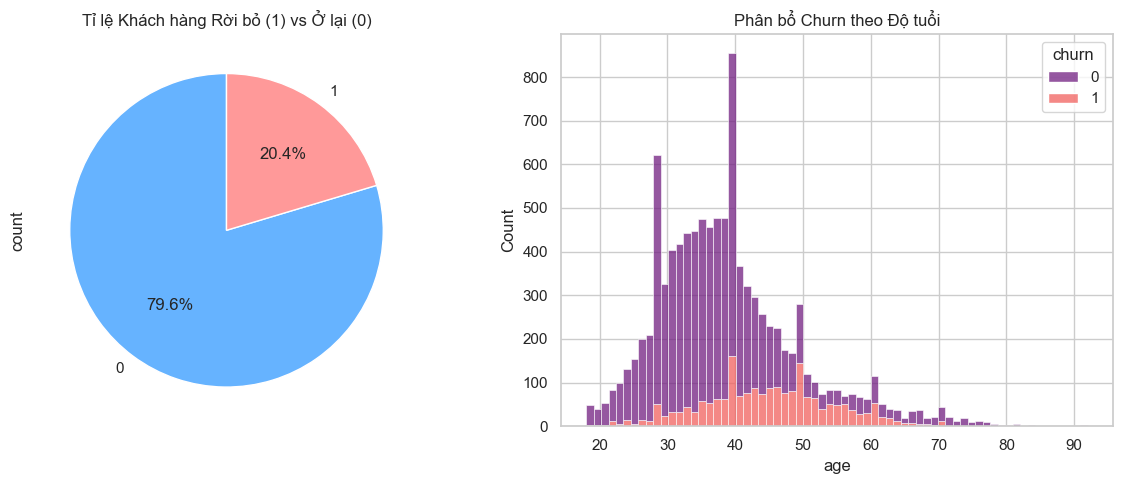

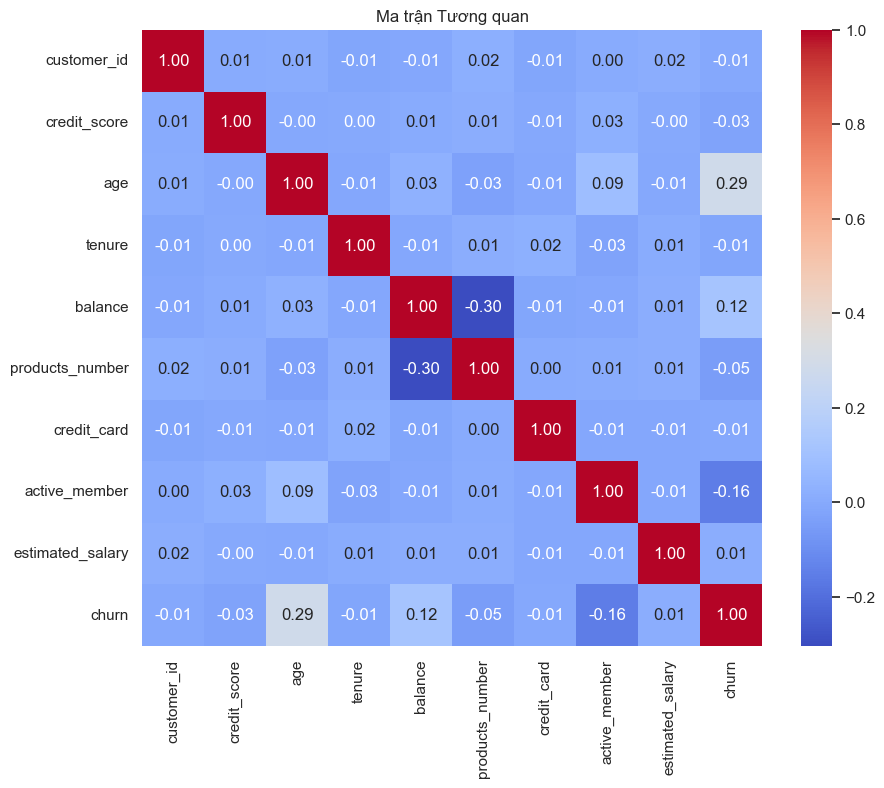

In [3]:
# Thiết lập giao diện biểu đồ
sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. Tỉ lệ Churn
plt.subplot(1, 2, 1)
df['churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Tỉ lệ Khách hàng Rời bỏ (1) vs Ở lại (0)')

# 2. Churn theo Độ tuổi (Age thường là yếu tố quan trọng)
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='age', hue='churn', multiple="stack", palette='magma')
plt.title('Phân bổ Churn theo Độ tuổi')

plt.tight_layout()
plt.show()

# Kiểm tra tương quan bằng Heatmap
plt.figure(figsize=(10, 8))
# Chỉ lấy các cột số để tính tương quan
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Ma trận Tương quan')
plt.show()

In [4]:
# Loại bỏ cột customer_id vì không mang giá trị dự báo
df_model = df.drop('customer_id', axis=1)

# Mã hóa các cột phân loại (Categorical)
# Country (France, Germany, Spain) và Gender (Male, Female)
le = LabelEncoder()
df_model['gender'] = le.fit_transform(df_model['gender'])

# Sử dụng One-Hot Encoding cho cột 'country' vì nó không có thứ bậc
df_model = pd.get_dummies(df_model, columns=['country'], drop_first=True)

# Chia features (X) và target (y)
X = df_model.drop('churn', axis=1)
y = df_model['churn']

# Chia tập Train và Test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu (Scaling) để các thuật toán chạy ổn định hơn
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Tiền xử lý hoàn tất. Kích thước tập Train:", X_train.shape)

Tiền xử lý hoàn tất. Kích thước tập Train: (8000, 11)


In [5]:
# Khởi tạo và huấn luyện mô hình
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Dự đoán trên tập Test
y_pred = model.predict(X_test)

print("Mô hình đã được huấn luyện xong!")

Mô hình đã được huấn luyện xong!


--- Báo cáo Phân loại (Classification Report) ---
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.76      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



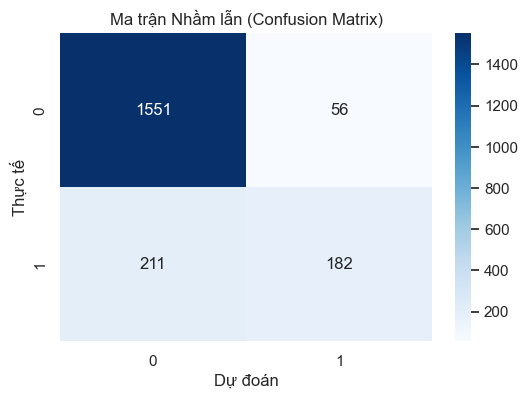

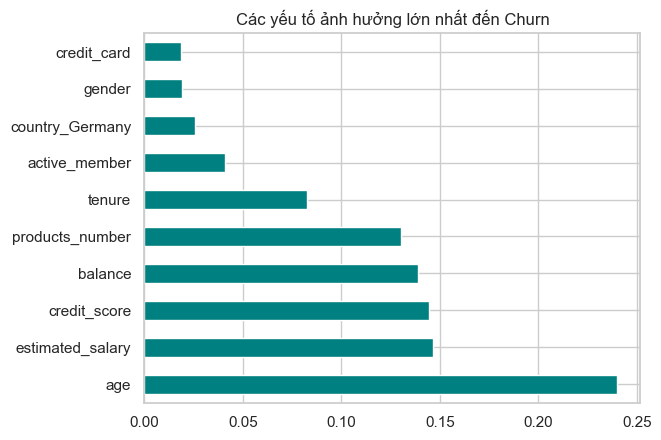

In [6]:
# In báo cáo phân loại
print("--- Báo cáo Phân loại (Classification Report) ---")
print(classification_report(y_test, y_pred))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Ma trận Nhầm lẫn (Confusion Matrix)')
plt.show()

# Hiển thị các tính năng quan trọng nhất (Feature Importance)
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Các yếu tố ảnh hưởng lớn nhất đến Churn')
plt.show()